# Employee Attrition

This dataset contains employee and termination-related information collected over a 10-year period from a manufacturing organization.
It includes details such as employee demographics, job roles, departments, employment duration, performance-related attributes, and termination status.
The dataset has a mix of numerical and categorical variables, along with missing values, making it suitable for data cleaning and exploratory data analysis (EDA).
Overall, it represents real-world organizational data used to understand workforce behavior and outcomes.

- Analyze employee termination patterns over time

- Identify factors that influence employee attrition or termination

- Understand relationships between employee attributes (such as role, experience, performance) and termination status

- Support data-driven decision-making for improving employee retention and workforce planning

- This dataset is well-suited for EDA, visualization, and predictive modeling related to employee attrition analysis.



# Libraries

In [2]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier

import pickle
import gradio as gr
import pickle
import numpy as np

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

https://www.kaggle.com/datasets/HRAnalyticRepository/employee-attrition-data

In [3]:

att_df=pd.read_csv(r'C:\Users\PC\OneDrive\Desktop\niyas\EDA\project\MFG10YearTerminationData.csv')
att_df

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49648,8258,12/1/2015 0:00,5/28/1994,8/19/2013,12/30/2015,21,2,Valemount,Dairy,Dairy Person,34,M,Male,Layoff,Involuntary,2015,TERMINATED,STORES
49649,8264,8/1/2013 0:00,6/13/1994,8/27/2013,8/30/2013,19,0,Vancouver,Customer Service,Cashier,44,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
49650,8279,12/1/2015 0:00,7/18/1994,9/15/2013,12/30/2015,21,2,White Rock,Customer Service,Cashier,39,F,Female,Layoff,Involuntary,2015,TERMINATED,STORES
49651,8296,12/1/2013 0:00,9/2/1994,10/9/2013,12/31/2013,19,0,Kelowna,Customer Service,Cashier,16,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES


## Base understanding










##### checking shape,head,tail,sample,info,describe,object describe

In [4]:
att_df.shape

(49653, 18)

In [5]:
att_df.head()

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE


In [6]:
att_df.tail()

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
49648,8258,12/1/2015 0:00,5/28/1994,8/19/2013,12/30/2015,21,2,Valemount,Dairy,Dairy Person,34,M,Male,Layoff,Involuntary,2015,TERMINATED,STORES
49649,8264,8/1/2013 0:00,6/13/1994,8/27/2013,8/30/2013,19,0,Vancouver,Customer Service,Cashier,44,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
49650,8279,12/1/2015 0:00,7/18/1994,9/15/2013,12/30/2015,21,2,White Rock,Customer Service,Cashier,39,F,Female,Layoff,Involuntary,2015,TERMINATED,STORES
49651,8296,12/1/2013 0:00,9/2/1994,10/9/2013,12/31/2013,19,0,Kelowna,Customer Service,Cashier,16,F,Female,Resignaton,Voluntary,2013,TERMINATED,STORES
49652,8321,12/1/2014 0:00,11/28/1994,11/24/2013,12/30/2014,20,1,Grand Forks,Customer Service,Cashier,13,F,Female,Layoff,Involuntary,2014,TERMINATED,STORES


In [7]:
att_df.sample()

,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
44892,7493,12/31/2011 0:00,7/21/1988,7/17/2010,1/1/1900,23,1,Port Coquitlam,Customer Service,Cashier,25,M,Male,Not Applicable,Not Applicable,2011,ACTIVE,STORES


In [8]:
att_df.describe()

,EmployeeID,age,length_of_service,store_name,STATUS_YEAR
count,49653.000000,49653.000000,49653.000000,49653.000000,49653.000000
mean,4859.495740,42.077035,10.434596,27.297605,2010.612612
std,1826.571142,12.427257,6.325286,13.514134,2.845577
min,1318.000000,19.000000,0.000000,1.000000,2006.000000
25%,3360.000000,31.000000,5.000000,16.000000,2008.000000
50%,5031.000000,42.000000,10.000000,28.000000,2011.000000
75%,6335.000000,53.000000,15.000000,42.000000,2013.000000
max,8336.000000,65.000000,26.000000,46.000000,2015.000000


In [9]:
att_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   EmployeeID           49653 non-null  int64 
 1   recorddate_key       49653 non-null  object
 2   birthdate_key        49653 non-null  object
 3   orighiredate_key     49653 non-null  object
 4   terminationdate_key  49653 non-null  object
 5   age                  49653 non-null  int64 
 6   length_of_service    49653 non-null  int64 
 7   city_name            49653 non-null  object
 8   department_name      49653 non-null  object
 9   job_title            49653 non-null  object
 10  store_name           49653 non-null  int64 
 11  gender_short         49653 non-null  object
 12  gender_full          49653 non-null  object
 13  termreason_desc      49653 non-null  object
 14  termtype_desc        49653 non-null  object
 15  STATUS_YEAR          49653 non-null  int64 
 16  STAT

In [10]:
att_df.describe(include=['O'])

,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,city_name,department_name,job_title,gender_short,gender_full,termreason_desc,termtype_desc,STATUS,BUSINESS_UNIT
count,49653,49653,49653,49653,49653,49653,49653,49653,49653,49653,49653,49653,49653
unique,130,5342,4415,1055,40,21,47,2,2,4,3,2,2
top,12/31/2013 0:00,4/27/1956,10/16/2005,1/1/1900,Vancouver,Meats,Meat Cutter,F,Female,Not Applicable,Not Applicable,ACTIVE,STORES
freq,5215,40,50,42450,11211,10269,9984,25898,25898,48168,48168,48168,49068


In [11]:
print('the feature of the dataset are:')
features_list=[feature for feature in att_df.columns]
for feature in features_list:
    print(feature)

the feature of the dataset are:
EmployeeID
recorddate_key
birthdate_key
orighiredate_key
terminationdate_key
age
length_of_service
city_name
department_name
job_title
store_name
gender_short
gender_full
termreason_desc
termtype_desc
STATUS_YEAR
STATUS
BUSINESS_UNIT


# Explanation of the features in the dataset:

**EmployeeID** – Unique ID assigned to each employee

**recorddate_key** – Date when the employee record was recorded

**birthdate_key** – Employee’s date of birth

**orighiredate_key** – Original date the employee was hired

**terminationdate_key** – Date the employee left the organization

**age** – Age of the employee

**length_of_service** – Total years worked in the organization

**city_name** – City where the employee works

**department_name** – Department of the employee

**job_title** – Job position or designation

**store_name** – Store or branch assigned to the employee

**gender_short** – Gender in short form (M/F)

**gender_full** – Gender in full form

**termreason_desc** – Reason for employee termination

**termtype_desc** – Type of termination (voluntary/involuntary)

**STATUS_YEAR** – Year of employee status record

**STATUS** – Current employment status (Active/Terminated)

**BUSINESS_UNIT** – Business unit or division of the organization



In [12]:
att_df.isnull().sum()

EmployeeID             0
recorddate_key         0
birthdate_key          0
orighiredate_key       0
terminationdate_key    0
age                    0
length_of_service      0
city_name              0
department_name        0
job_title              0
store_name             0
gender_short           0
gender_full            0
termreason_desc        0
termtype_desc          0
STATUS_YEAR            0
STATUS                 0
BUSINESS_UNIT          0
dtype: int64

In [13]:
att_df["recorddate_key"].unique()

array(['12/31/2006 0:00', '12/31/2007 0:00', '12/31/2008 0:00',
       '12/31/2009 0:00', '12/31/2010 0:00', '12/31/2011 0:00',
       '12/31/2012 0:00', '12/31/2013 0:00', '12/31/2014 0:00',
       '12/31/2015 0:00', '2/1/2009 0:00', '2/1/2014 0:00',
       '3/1/2014 0:00', '3/1/2009 0:00', '9/1/2012 0:00', '4/1/2014 0:00',
       '4/1/2009 0:00', '5/1/2009 0:00', '5/1/2014 0:00',
       '12/1/2014 0:00', '6/1/2009 0:00', '6/1/2014 0:00',
       '7/1/2014 0:00', '7/1/2009 0:00', '8/1/2009 0:00', '8/1/2014 0:00',
       '12/1/2009 0:00', '9/1/2014 0:00', '9/1/2009 0:00',
       '10/1/2009 0:00', '10/1/2014 0:00', '11/1/2014 0:00',
       '11/1/2009 0:00', '7/1/2007 0:00', '1/1/2015 0:00',
       '1/1/2010 0:00', '12/1/2010 0:00', '2/1/2015 0:00',
       '2/1/2010 0:00', '3/1/2015 0:00', '3/1/2010 0:00', '4/1/2010 0:00',
       '4/1/2015 0:00', '5/1/2015 0:00', '5/1/2010 0:00', '6/1/2010 0:00',
       '6/1/2015 0:00', '7/1/2010 0:00', '7/1/2015 0:00',
       '12/1/2015 0:00', '3/1/2011 

In [14]:
att_df["BUSINESS_UNIT"].unique()

array(['HEADOFFICE', 'STORES'], dtype=object)

In [15]:
att_df.describe()

,EmployeeID,age,length_of_service,store_name,STATUS_YEAR
count,49653.000000,49653.000000,49653.000000,49653.000000,49653.000000
mean,4859.495740,42.077035,10.434596,27.297605,2010.612612
std,1826.571142,12.427257,6.325286,13.514134,2.845577
min,1318.000000,19.000000,0.000000,1.000000,2006.000000
25%,3360.000000,31.000000,5.000000,16.000000,2008.000000
50%,5031.000000,42.000000,10.000000,28.000000,2011.000000
75%,6335.000000,53.000000,15.000000,42.000000,2013.000000
max,8336.000000,65.000000,26.000000,46.000000,2015.000000


## feature wise Data Analysis

In [16]:
def display_cols_info(cols):
    for col in cols:
        c = att_df[col]   # short alias

        print("-" * 30)
        print(f"Column: {col}")
        print("-" * 30)

        print("Datatype:", c.dtype)
        print("Null values:", c.isnull().sum())
        print(c.describe(), "\n")

        if c.nunique() < 10:
            print("Unique values:", c.unique())
            print("Frequency:\n", c.value_counts())
        else:
            print(f"Frequency not shown ({c.nunique()} unique values).")

# Call the function
display_cols_info(att_df.columns)


# “This function prints complete information about each dataset column including datatype, missing values, statistics, and frequencies.”

------------------------------
Column: EmployeeID
------------------------------
Datatype: int64
Null values: 0
count    49653.000000
mean      4859.495740
std       1826.571142
min       1318.000000
25%       3360.000000
50%       5031.000000
75%       6335.000000
max       8336.000000
Name: EmployeeID, dtype: float64 

Frequency not shown (6284 unique values).
------------------------------
Column: recorddate_key
------------------------------
Datatype: object
Null values: 0
count               49653
unique                130
top       12/31/2013 0:00
freq                 5215
Name: recorddate_key, dtype: object 

Frequency not shown (130 unique values).
------------------------------
Column: birthdate_key
------------------------------
Datatype: object
Null values: 0
count         49653
unique         5342
top       4/27/1956
freq             40
Name: birthdate_key, dtype: object 

Frequency not shown (5342 unique values).
------------------------------
Column: orighiredate_key
----

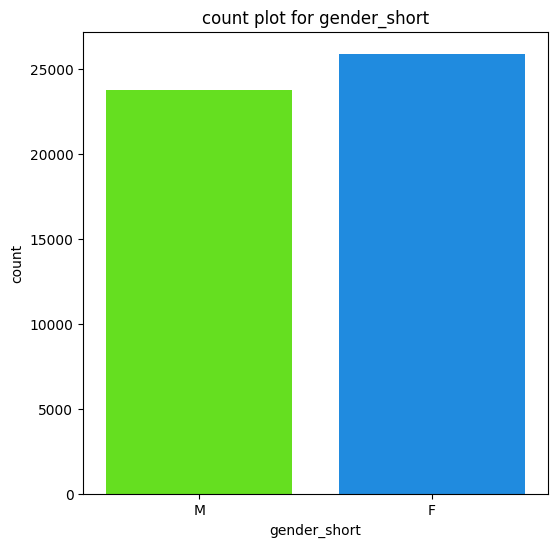

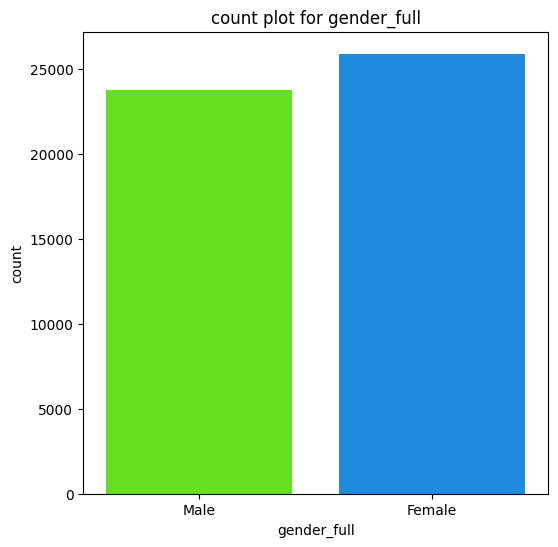

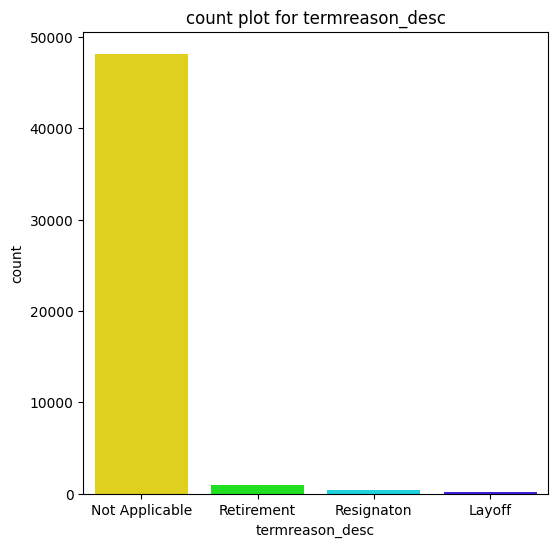

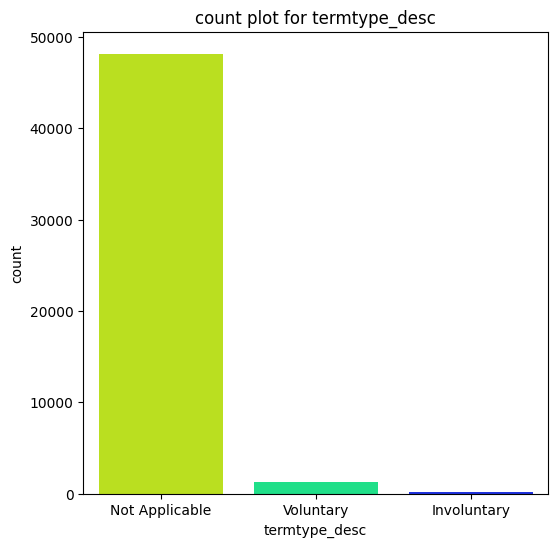

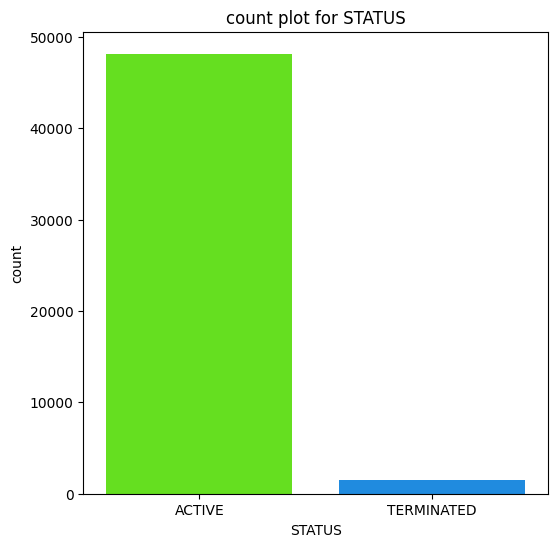

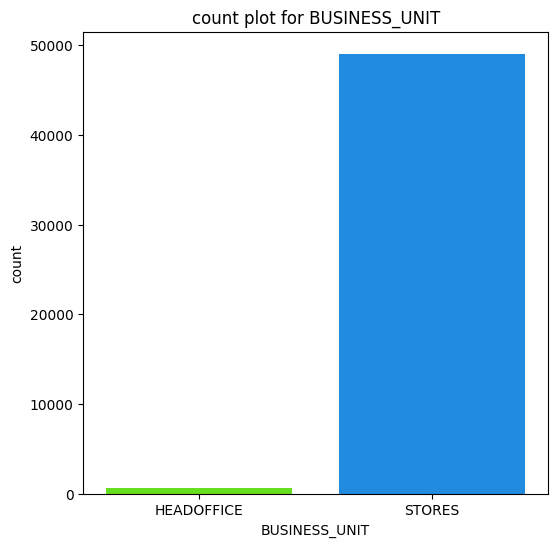

In [17]:
categorical_columns=att_df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns[1:]:
    if att_df[col].nunique()<10:
        plt.figure(figsize=(6,6))
        sns.countplot(data=att_df,x=col,hue=col,palette='gist_rainbow')
        plt.title(f'count plot for {col}')
        plt.show()

        # “This code identifies categorical columns and creates count plots for columns with fewer unique values to understand category distribution.”

###  Most Employees are:

- Gender : Female
- Termreason_desc : Not Applicable
- Status :Active
- Business_Unit : Stores

In [18]:
att_df.describe()

,EmployeeID,age,length_of_service,store_name,STATUS_YEAR
count,49653.000000,49653.000000,49653.000000,49653.000000,49653.000000
mean,4859.495740,42.077035,10.434596,27.297605,2010.612612
std,1826.571142,12.427257,6.325286,13.514134,2.845577
min,1318.000000,19.000000,0.000000,1.000000,2006.000000
25%,3360.000000,31.000000,5.000000,16.000000,2008.000000
50%,5031.000000,42.000000,10.000000,28.000000,2011.000000
75%,6335.000000,53.000000,15.000000,42.000000,2013.000000
max,8336.000000,65.000000,26.000000,46.000000,2015.000000


# data cleaning

In [19]:
att_df.isnull().sum()

EmployeeID             0
recorddate_key         0
birthdate_key          0
orighiredate_key       0
terminationdate_key    0
age                    0
length_of_service      0
city_name              0
department_name        0
job_title              0
store_name             0
gender_short           0
gender_full            0
termreason_desc        0
termtype_desc          0
STATUS_YEAR            0
STATUS                 0
BUSINESS_UNIT          0
dtype: int64

In [20]:
att_df.duplicated().sum()

np.int64(0)

In [21]:
att_df.columns

Index(['EmployeeID', 'recorddate_key', 'birthdate_key', 'orighiredate_key',
       'terminationdate_key', 'age', 'length_of_service', 'city_name',
       'department_name', 'job_title', 'store_name', 'gender_short',
       'gender_full', 'termreason_desc', 'termtype_desc', 'STATUS_YEAR',
       'STATUS', 'BUSINESS_UNIT'],
      dtype='object')

In [22]:
att_df.drop(columns='gender_short',inplace=True)

In [23]:
att_df.drop(columns='termtype_desc',inplace=True)

# Feature Engineering

In [24]:
att_df["orighiredate_key"] = pd.to_datetime(att_df["orighiredate_key"])


att_df["orighiredate_key_day"] = att_df["orighiredate_key"].dt.day
att_df["orighiredate_key_month"] = att_df["orighiredate_key"].dt.month
att_df["orighiredate_key_year"] = att_df["orighiredate_key"].dt.year

att_df.drop(columns=["orighiredate_key"], inplace=True)

In [25]:
att_df["recorddate_key"] = pd.to_datetime(att_df["recorddate_key"])


att_df["recorddate_key_day"] = att_df["recorddate_key"].dt.day
att_df["recorddate_key_month"] = att_df["recorddate_key"].dt.month
att_df["recorddate_keyy_year"] = att_df["recorddate_key"].dt.year

att_df.drop(columns=["recorddate_key"], inplace=True)

In [26]:
att_df["birthdate_key"] = pd.to_datetime(att_df["birthdate_key"])


att_df["birthdate_key_day"] = att_df["birthdate_key"].dt.day
att_df["birthdate_key_month"] = att_df["birthdate_key"].dt.month
att_df["birthdate_key_year"] = att_df["birthdate_key"].dt.year



att_df.drop(columns=["birthdate_key"], inplace=True)



#  encoding

In [27]:
categorical_columns=att_df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:",categorical_columns)


Categorical columns: ['terminationdate_key', 'city_name', 'department_name', 'job_title', 'gender_full', 'termreason_desc', 'STATUS', 'BUSINESS_UNIT']


# Label encoding

In [28]:
att_df["length_of_service"].unique()

array([17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 16, 15, 14, 13, 12, 11, 10,
        9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [29]:
# from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cols = [
    'city_name',
    'department_name',
    'job_title',
    'terminationdate_key',
    'gender_full',
    'termreason_desc',
    'BUSINESS_UNIT'
]

for col in cols:
    le = LabelEncoder()
    att_df[col] = le.fit_transform(att_df[col])
    label_encoders[col] = le


In [30]:
att_df['STATUS'].unique()

array(['ACTIVE', 'TERMINATED'], dtype=object)

# Ordinal Encoding

In [31]:
att_df['STATUS']=att_df['STATUS'].map({'ACTIVE':1,'TERMINATED':0})

In [32]:
att_df

,EmployeeID,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_full,termreason_desc,...,BUSINESS_UNIT,orighiredate_key_day,orighiredate_key_month,orighiredate_key_year,recorddate_key_day,recorddate_key_month,recorddate_keyy_year,birthdate_key_day,birthdate_key_month,birthdate_key_year
0,1318,0,52,17,34,9,7,35,1,1,...,0,28,8,1989,31,12,2006,3,1,1954
1,1318,0,53,18,34,9,7,35,1,1,...,0,28,8,1989,31,12,2007,3,1,1954
2,1318,0,54,19,34,9,7,35,1,1,...,0,28,8,1989,31,12,2008,3,1,1954
3,1318,0,55,20,34,9,7,35,1,1,...,0,28,8,1989,31,12,2009,3,1,1954
4,1318,0,56,21,34,9,7,35,1,1,...,0,28,8,1989,31,12,2010,3,1,1954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49648,8258,345,21,2,33,7,14,34,1,0,...,1,19,8,2013,1,12,2015,28,5,1994
49649,8264,948,19,0,34,6,9,44,0,2,...,1,27,8,2013,1,8,2013,13,6,1994
49650,8279,345,21,2,38,6,9,39,0,0,...,1,15,9,2013,1,12,2015,18,7,1994
49651,8296,349,19,0,15,6,9,16,0,2,...,1,9,10,2013,1,12,2013,2,9,1994


In [33]:
att_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   EmployeeID              49653 non-null  int64
 1   terminationdate_key     49653 non-null  int64
 2   age                     49653 non-null  int64
 3   length_of_service       49653 non-null  int64
 4   city_name               49653 non-null  int64
 5   department_name         49653 non-null  int64
 6   job_title               49653 non-null  int64
 7   store_name              49653 non-null  int64
 8   gender_full             49653 non-null  int64
 9   termreason_desc         49653 non-null  int64
 10  STATUS_YEAR             49653 non-null  int64
 11  STATUS                  49653 non-null  int64
 12  BUSINESS_UNIT           49653 non-null  int64
 13  orighiredate_key_day    49653 non-null  int32
 14  orighiredate_key_month  49653 non-null  int32
 15  orighiredate_key_ye

# data transformation

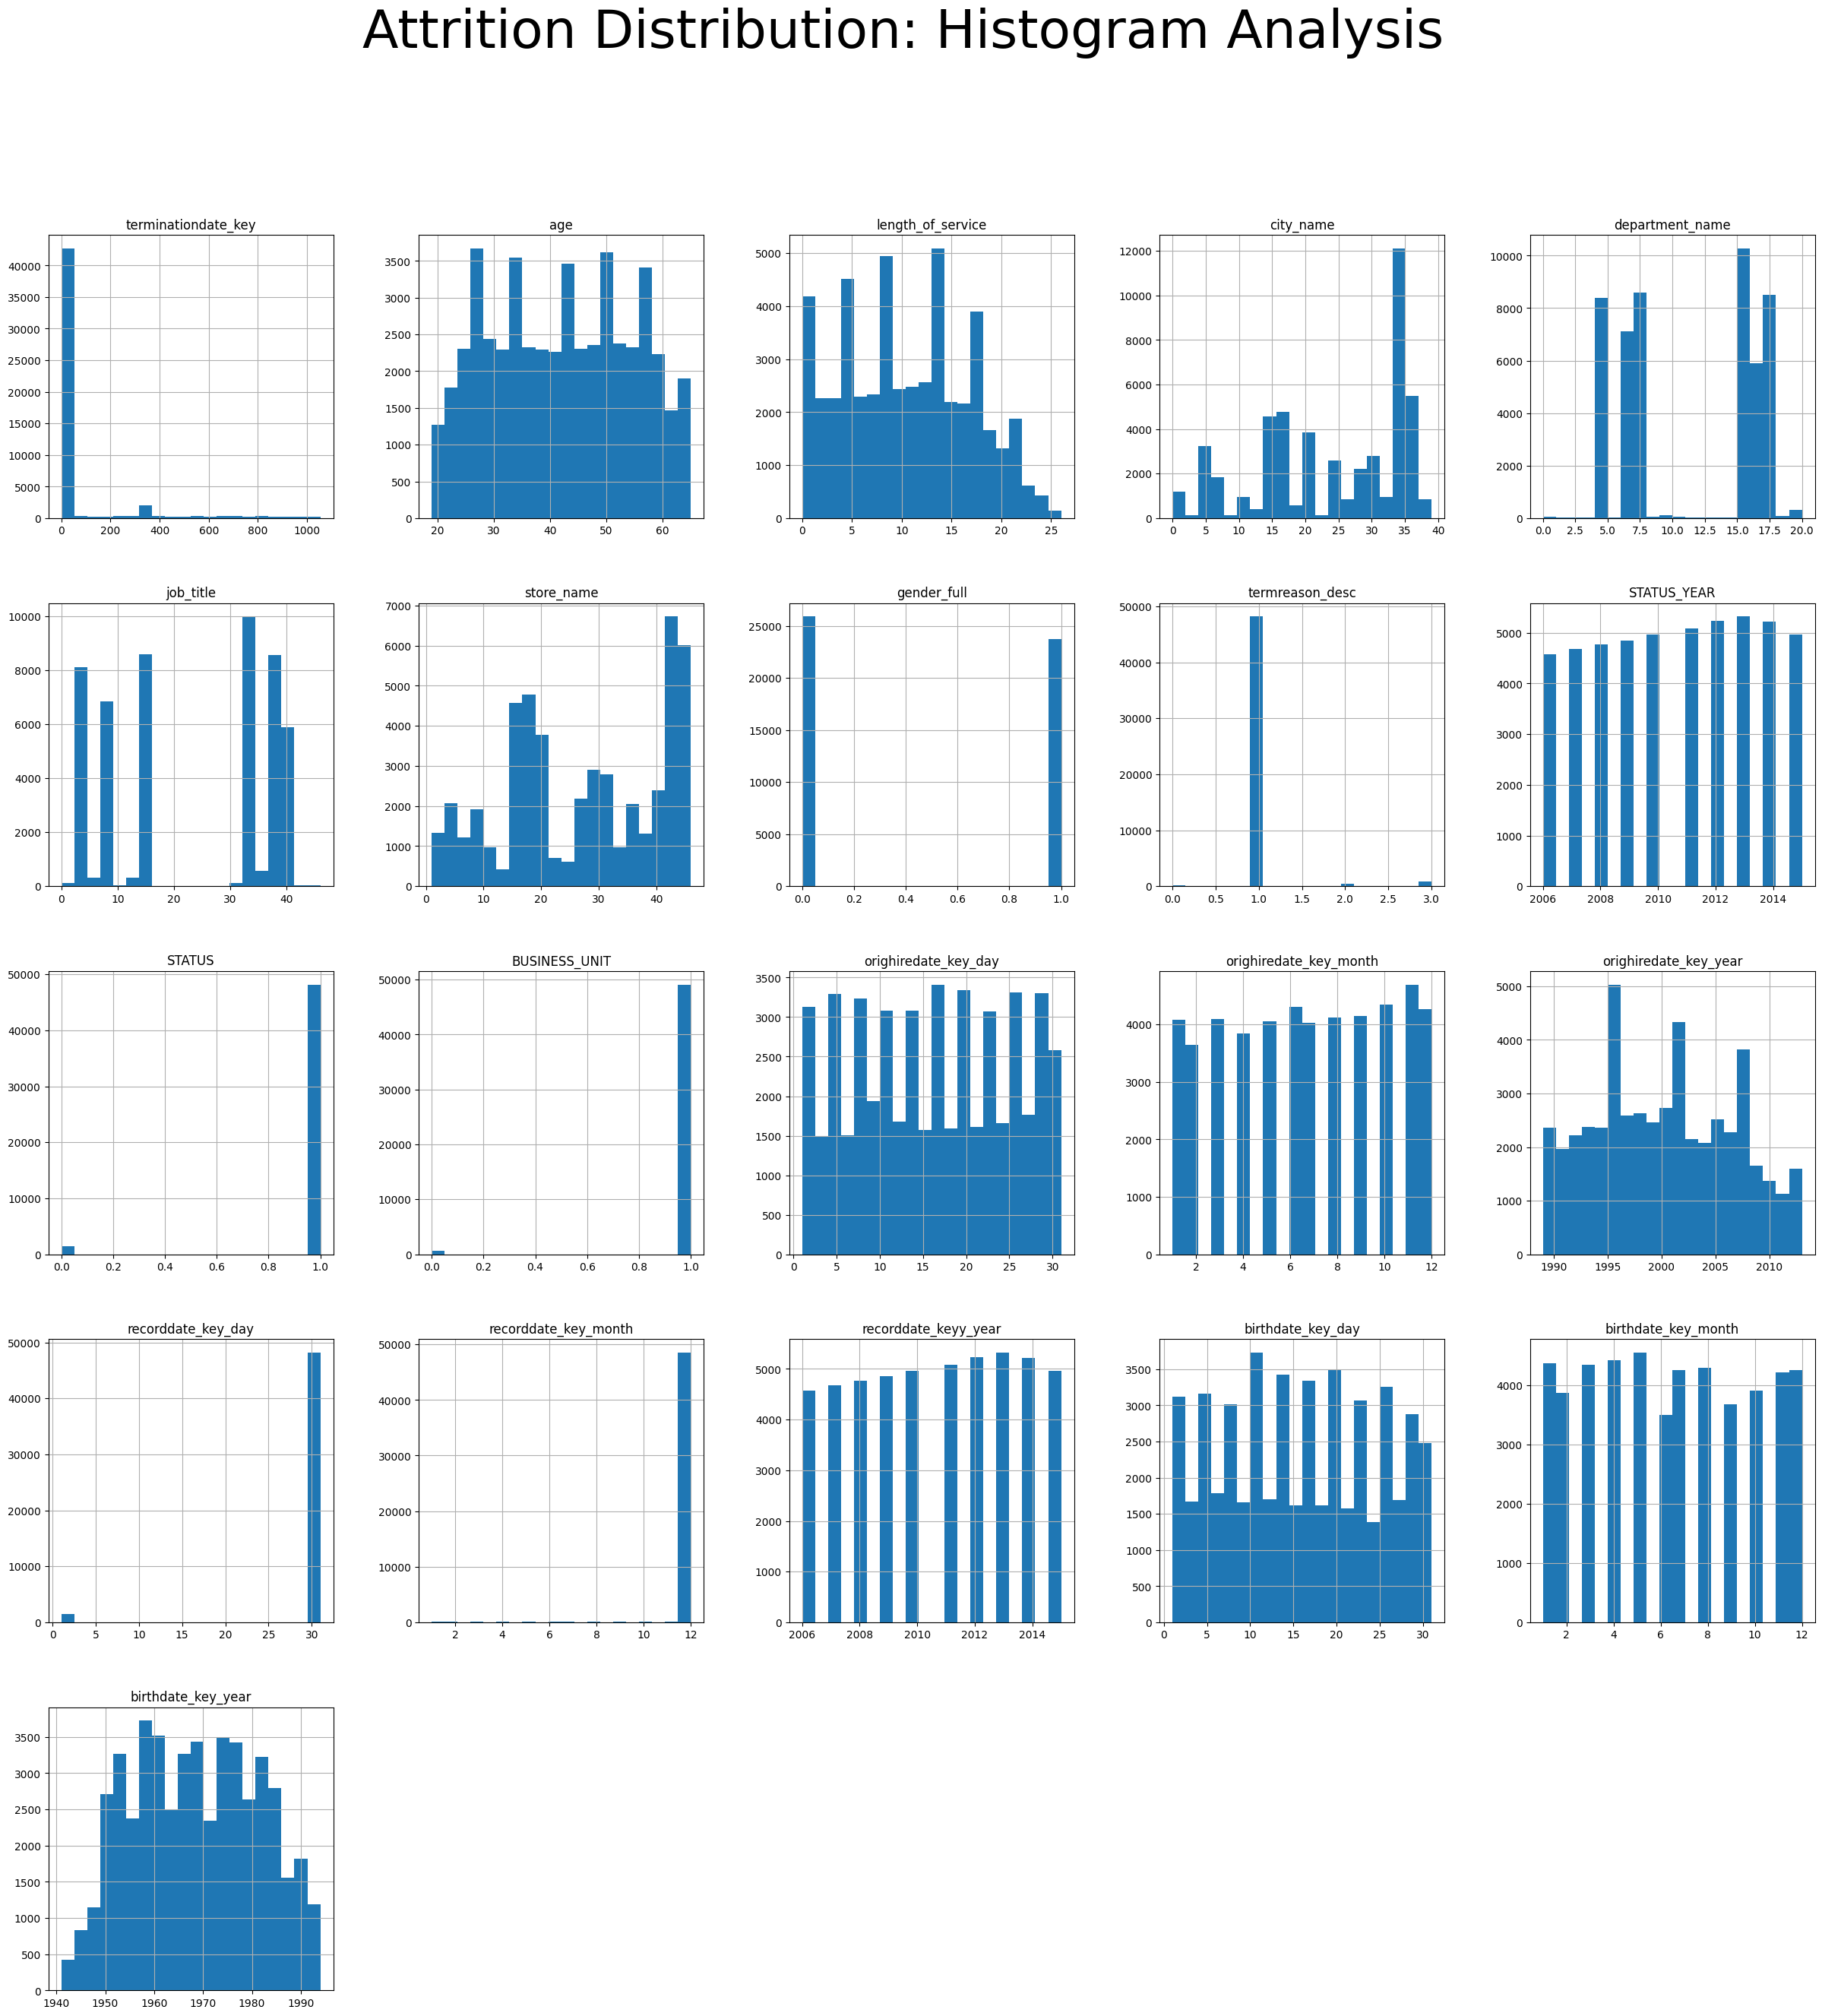

In [34]:
# Assume Student_ID is the first column
att_df.iloc[:, 1:].hist(bins=20, figsize=(30,30))

plt.suptitle("Attrition Distribution: Histogram Analysis", fontsize=50)
plt.show()



In [35]:
#calculate skewness for each column
skewness=att_df.skew()

#sort the skewness values in ascending order
sorted_skewness=skewness.sort_values(ascending=True)

#display the sorted skewness values
print(sorted_skewness)

BUSINESS_UNIT            -9.049519
recorddate_key_month     -8.258656
recorddate_key_day       -5.519876
STATUS                   -5.519876
city_name                -0.515951
store_name               -0.162204
EmployeeID               -0.139642
job_title                -0.119461
department_name          -0.076217
recorddate_keyy_year     -0.059739
STATUS_YEAR              -0.059739
orighiredate_key_month   -0.059228
orighiredate_key_day     -0.007013
age                       0.023094
birthdate_key_year        0.027704
birthdate_key_day         0.032602
birthdate_key_month       0.033810
gender_full               0.086402
orighiredate_key_year     0.142283
length_of_service         0.148060
terminationdate_key       3.087537
termreason_desc           5.823095
dtype: float64


In [36]:
att_df['terminationdate_key']=np.log1p(att_df['terminationdate_key'])

In [37]:

skewness=att_df.skew()
sorted_skewness=skewness.sort_values(ascending=True)
print(sorted_skewness)

BUSINESS_UNIT            -9.049519
recorddate_key_month     -8.258656
recorddate_key_day       -5.519876
STATUS                   -5.519876
city_name                -0.515951
store_name               -0.162204
EmployeeID               -0.139642
job_title                -0.119461
department_name          -0.076217
recorddate_keyy_year     -0.059739
STATUS_YEAR              -0.059739
orighiredate_key_month   -0.059228
orighiredate_key_day     -0.007013
age                       0.023094
birthdate_key_year        0.027704
birthdate_key_day         0.032602
birthdate_key_month       0.033810
gender_full               0.086402
orighiredate_key_year     0.142283
length_of_service         0.148060
terminationdate_key       2.091077
termreason_desc           5.823095
dtype: float64


# removing unwanted features

<Axes: >

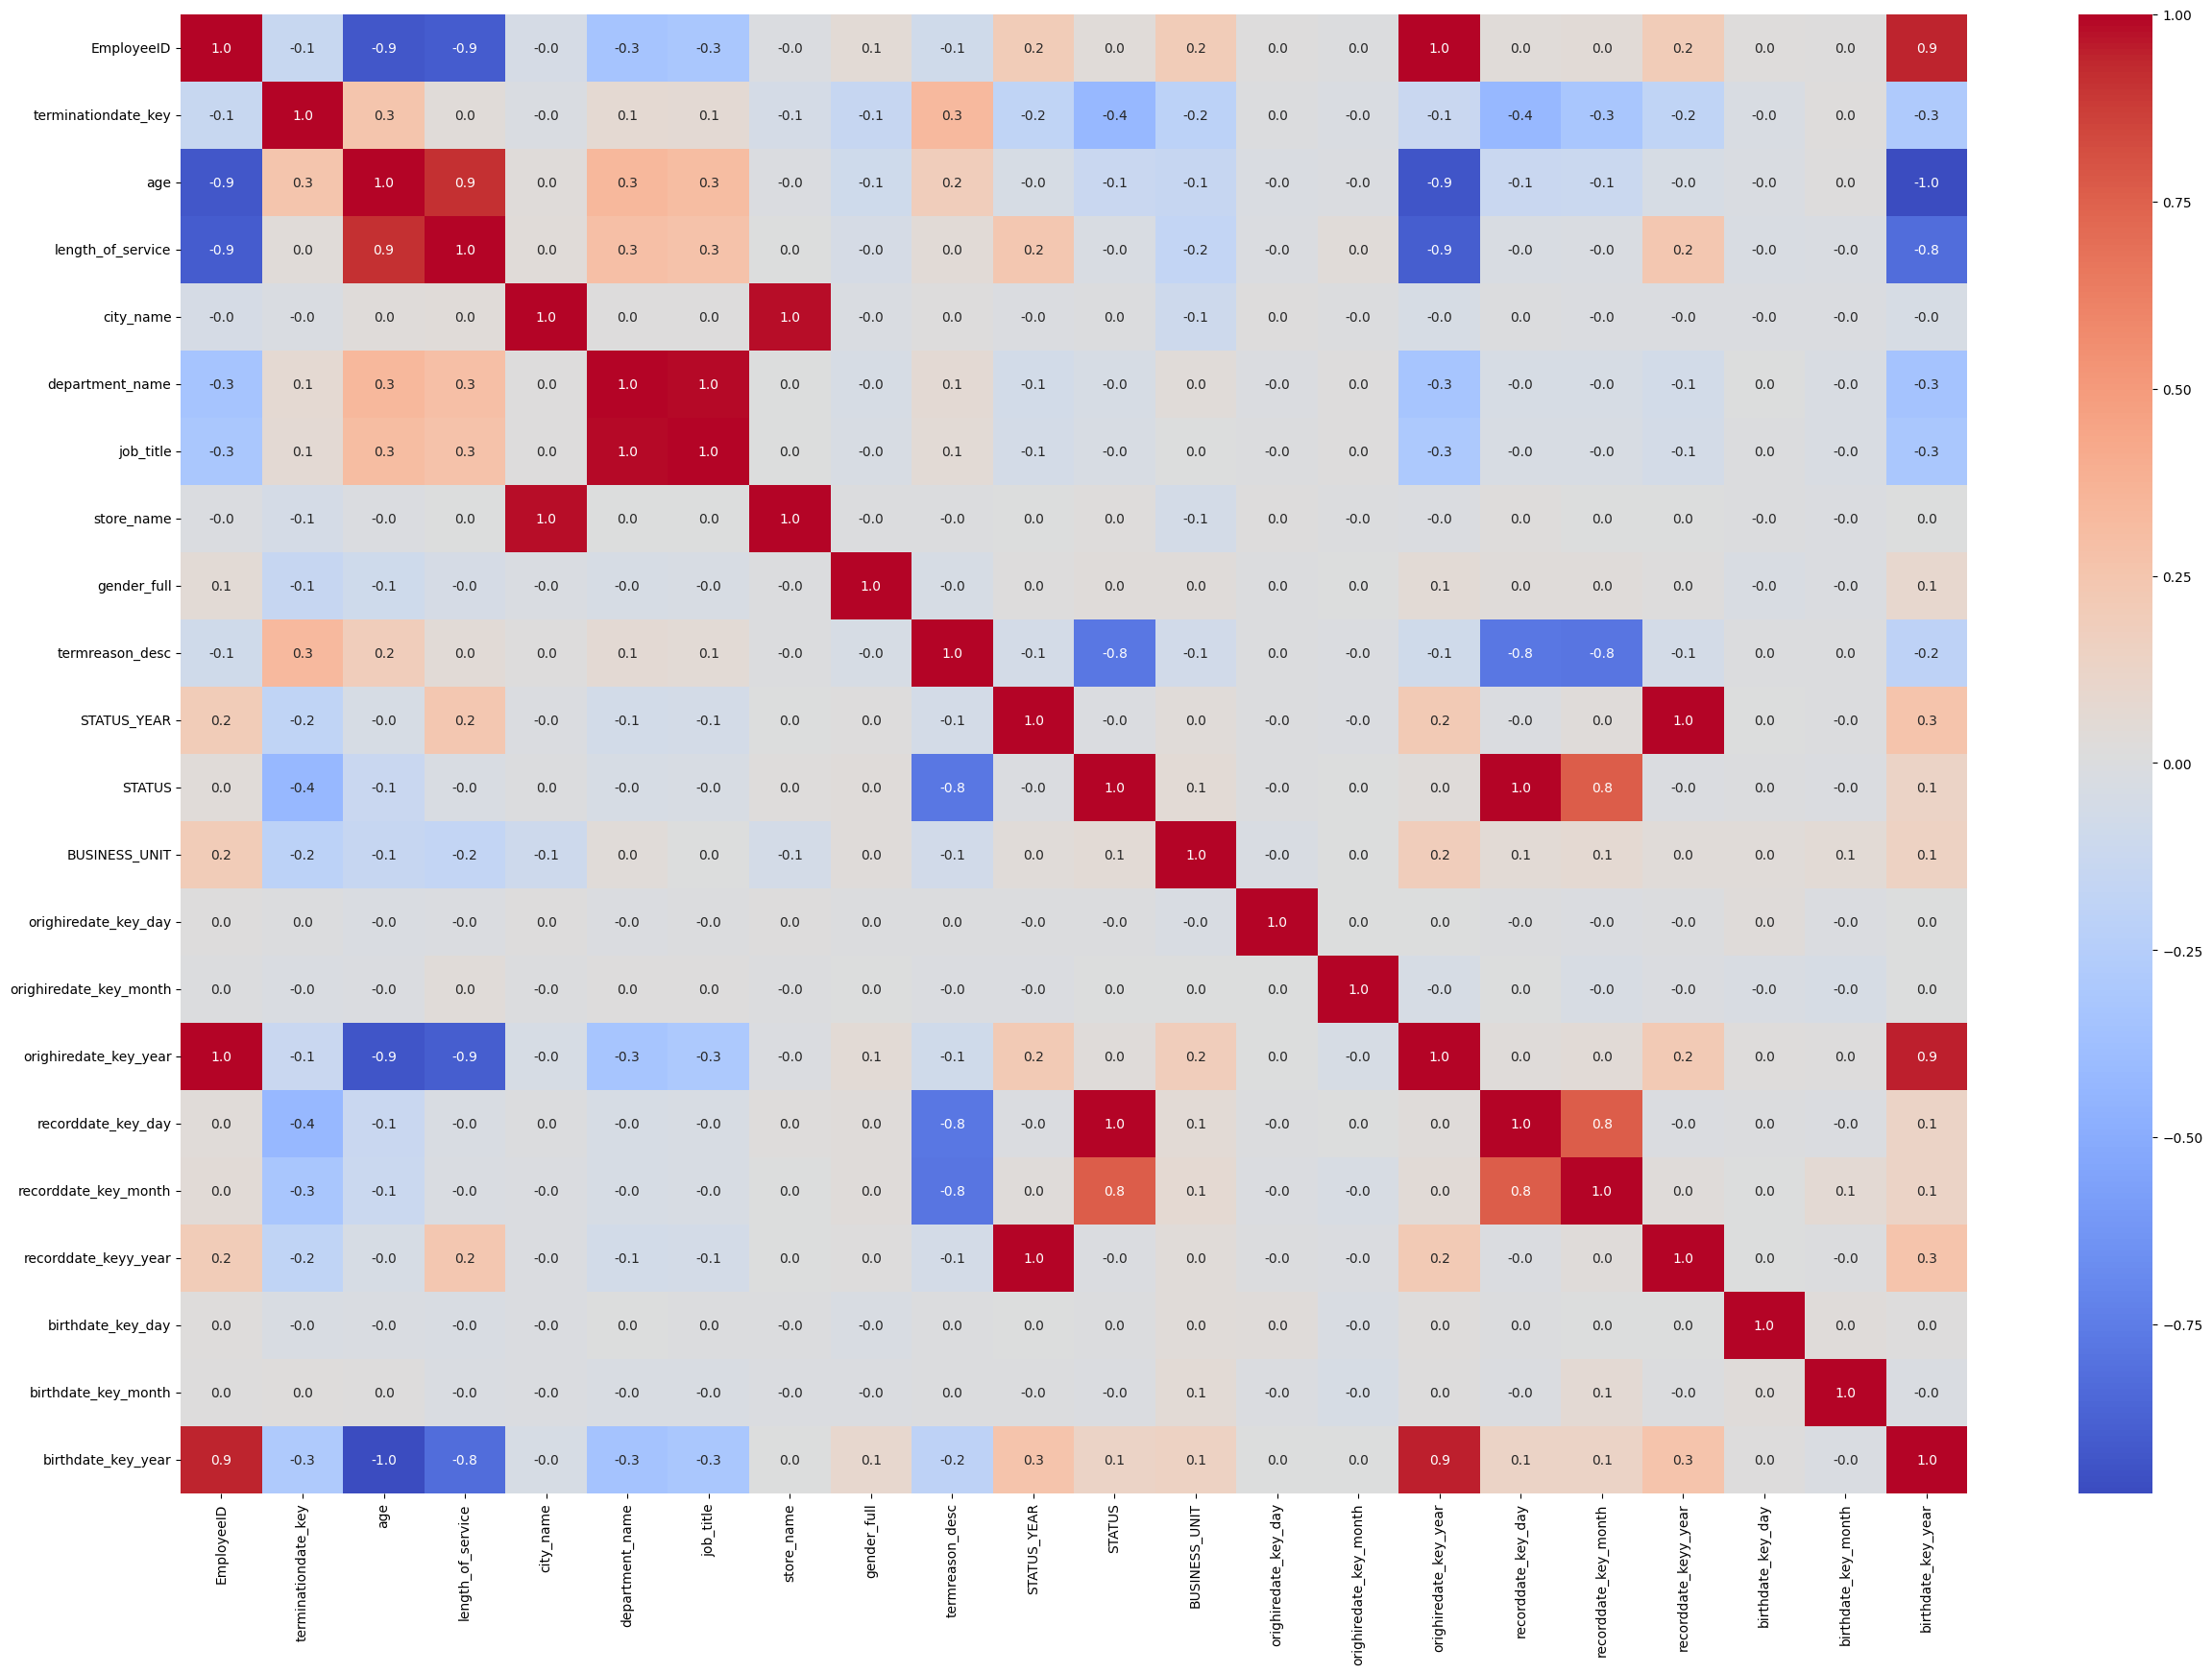

In [38]:
plt.figure(figsize=(30,20))
att_df.corr(numeric_only=True)
sns.heatmap(att_df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt="0.1f")

In [39]:
correlation_matrix=att_df.corr()
threshold=0.5  # set the correlation threshold

# find pairs of faetures with high correlation:

highly_correlated_pairs=[]
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        # check if the absolute correlation exceeds the threshold:

        if abs(correlation_matrix.iloc[i,j])>threshold:
            highly_correlated_pairs.append((correlation_matrix.columns[i],correlation_matrix.columns[j]))

#  print all pairs of highly correlated features:
print(highly_correlated_pairs)


[('age', 'EmployeeID'), ('length_of_service', 'EmployeeID'), ('length_of_service', 'age'), ('job_title', 'department_name'), ('store_name', 'city_name'), ('STATUS', 'termreason_desc'), ('orighiredate_key_year', 'EmployeeID'), ('orighiredate_key_year', 'age'), ('orighiredate_key_year', 'length_of_service'), ('recorddate_key_day', 'termreason_desc'), ('recorddate_key_day', 'STATUS'), ('recorddate_key_month', 'termreason_desc'), ('recorddate_key_month', 'STATUS'), ('recorddate_key_month', 'recorddate_key_day'), ('recorddate_keyy_year', 'STATUS_YEAR'), ('birthdate_key_year', 'EmployeeID'), ('birthdate_key_year', 'age'), ('birthdate_key_year', 'length_of_service'), ('birthdate_key_year', 'orighiredate_key_year')]


In [40]:
cols_to_drop = [
    "job_title",
    "EmployeeID",
    "length_of_service",
    "city_name",
    "orighiredate_key_year",
    "recorddate_key_day",
    "termreason_desc",
    "birthdate_key_year",
    "recorddate_keyy_year"
]

att_df.drop(columns=cols_to_drop, inplace=True)


In [41]:
correlation_matrix=att_df.corr()
threshold=0.5  # set the correlation threshold

# find pairs of faetures with high correlation:

highly_correlated_pairs=[]
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        # check if the absolute correlation exceeds the threshold:

        if abs(correlation_matrix.iloc[i,j])>threshold:
            highly_correlated_pairs.append((correlation_matrix.columns[i],correlation_matrix.columns[j]))

#  print all pairs of highly correlated features:
print(highly_correlated_pairs)

[('recorddate_key_month', 'STATUS')]


# Boxplot

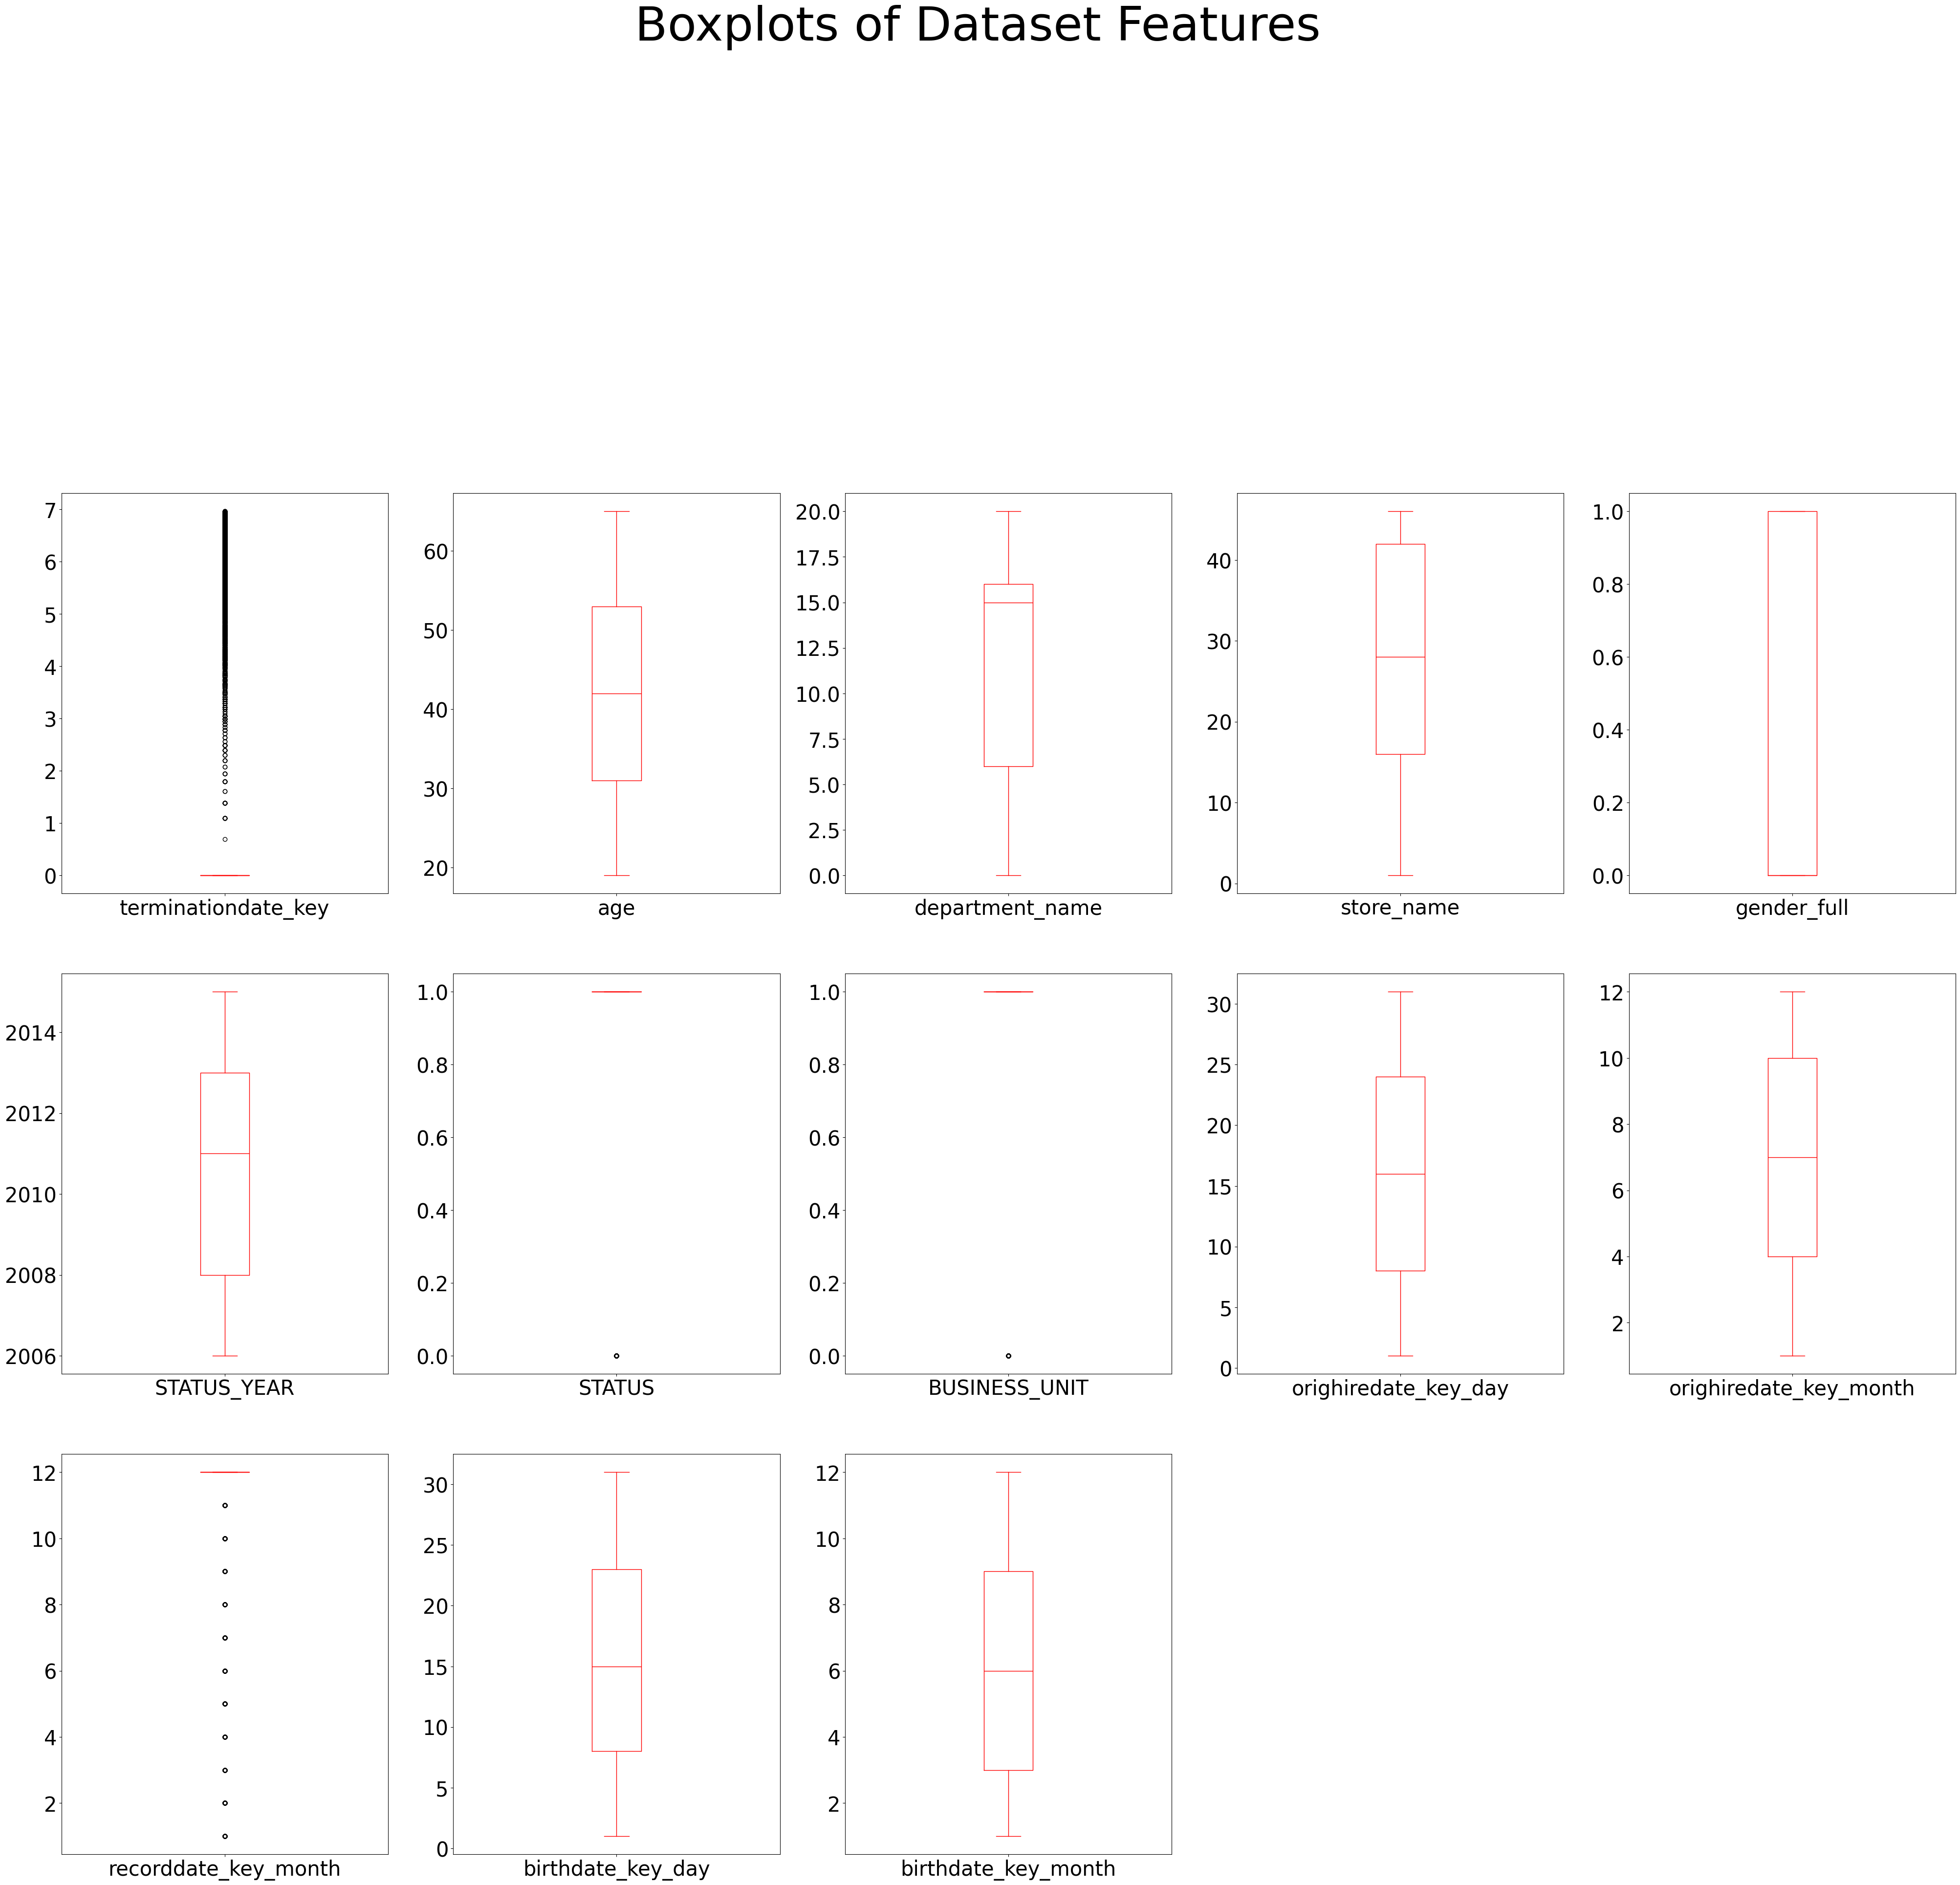

In [42]:
att_df.plot(kind="box",subplots=True,layout=(8,5),figsize=(50,100),color="red",fontsize=30)
plt.suptitle("Boxplots of Dataset Features",fontsize=70)
plt.show()

# Remove Outliers

In [43]:
att_df_copy=att_df.copy()

def remove_outliers_iqr(att_df,exclude_column):
    # loop through numeric columns
    for column in att_df.select_dtypes(include=["number"]):
        if column in exclude_column:
            continue # skip the excluded columns

        q1=att_df[column].quantile(0.25)
        q3=att_df[column].quantile(0.75)
        IQR=q3-q1

        # define outliers bounds
        lower_bound=q1-1.5*IQR
        upper_bound=q3+1.5*IQR

        # filter out the outliers:
        df=att_df[(att_df[column]>=lower_bound)&(att_df[column]<=upper_bound)]
    return df

# define the columns to exclude (target and descrete columns)
exclude_columns=["terminationdate_key"]

# remove the outliers:
att_df=remove_outliers_iqr(att_df,exclude_columns)

# print the shapes of the data before and after removing outliers:

print("Shape of the data before removing the otliers:",att_df_copy.shape)
print("shape of the data after removing the outliers:",att_df.shape)
print("Number of outliers removed:",att_df_copy.shape[0]-att_df.shape[0])

Shape of the data before removing the otliers: (49653, 13)
shape of the data after removing the outliers: (49653, 13)
Number of outliers removed: 0


In [44]:
att_df['STATUS'].value_counts()

STATUS
1    48168
0     1485
Name: count, dtype: int64

# model Building

In [45]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,root_mean_squared_error

# Features
X = att_df.drop("STATUS", axis=1)

# Target
y = att_df["STATUS"]

print(X.shape, y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,stratify=y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("Recall score:",recall_score(y_test,y_pred))




(49653, 12) (49653,)
Accuracy Score: 0.999295136441446
precision_score: 0.9992739342391868
Recall score: 1.0


# Final Report

* Analyzed employee data to identify key factors influencing attrition.

* Performed data preprocessing, EDA, and feature selection.

* Built a Logistic Regression model to predict employee attrition and support HR decision-making

* This project presents an end-to-end machine learning workflow using real-world Employee Attrition data.

*  It includes problem definition, data inspection, preprocessing (handling missing values, IQR-based outlier treatment, feature engineering), categorical encoding, and feature scaling.

* Exploratory Data Analysis (EDA) was performed to identify data patterns and key factors affecting Attrition Status.

* The data was split into training and testing sets, and multiple regression models were evaluated using MAE, MSE, RMSE, and R² score.

In [46]:

# from sklearn.ensemble import RandomForestRegressor

# Save the classification model
r_model = RandomForestRegressor()
r_model.fit(X_train,y_train.values.ravel())
with open ('Attrition.pkl','wb') as file:
    pickle.dump(r_model,file)

In [47]:
# import pickle

with open('Attrition.pkl', 'rb') as file:
    loaded_model = pickle.load(file)


In [ ]:
# import gradio as gr
# import pickle
# import numpy as np

# =====================================
# MANUAL MAPPINGS (FIXED & EXPLICIT)
# =====================================

department_map = {
    "Executive": 0,
    "Store Management": 1,
    "Meats": 2,
    "Recruitment": 3,
    "Training": 4,
    "Labor Relations": 5,
    "HR Technology": 6,
    "Employee Records": 7,
    "Compensation": 8,
    "Legal": 9,
    "Produce": 10,
    "Accounts Receivable": 11,
    "Bakery": 12,
    "Information Technology": 13,
    "Accounts Payable": 14,
    "Audit": 15,
    "Accounting": 16,
    "Investment": 17,
    "Dairy": 18,
    "Processed Foods": 19,
    "Customer Service": 20
}

gender_map = {
    "Male": 0,
    "Female": 1
}

business_unit_map = {
    "HEADOFFICE": 0,
    "STORES": 1
}

# status_map = {
#     "Active": 0,
#     "Terminated": 1
# }

# =====================================
# LOAD TRAINED MODEL (PICKLE)
# =====================================
with open("Attrition.pkl", "rb") as f:
    model = pickle.load(f)

# =====================================
# PREDICTION FUNCTION
# =====================================
def predict(
    terminationdate_key,
    age,
    department_name,
    store_name,
    gender_full,
    status_year,
    business_unit,
    orighire_day,
    orighire_month,
    record_month,
    birth_day,
    birth_month
):
    try:
        input_data = np.array([[ 
            terminationdate_key,
            age,
            department_map[department_name],
            store_name,                          # already numeric
            gender_map[gender_full],
            status_year,
            # status_map[status],
            business_unit_map[business_unit],
            orighire_day,
            orighire_month,
            record_month,
            birth_day,
            birth_month
        ]])
    except KeyError:
        return "Error: Invalid text value entered"

    prediction = model.predict(input_data)[0]
    return "Attrition: Yes" if prediction == 1 else "Attrition: No"

# =====================================
# GRADIO INTERFACE
# =====================================
interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Termination Date Key"),
        gr.Number(label="Age"),

        gr.Dropdown(
            choices=list(department_map.keys()),
            label="Department Name"
        ),

        gr.Number(label="Store Name (Encoded ID)"),

        gr.Dropdown(
            choices=list(gender_map.keys()),
            label="Gender"
        ),

        gr.Number(label="Status Year"),

        # gr.Dropdown(
        #     choices=list(status_map.keys()),
        #     label="Status"
        # ),

        gr.Dropdown(
            choices=list(business_unit_map.keys()),
            label="Business Unit"
        ),

        gr.Number(label="Hire Day"),
        gr.Number(label="Hire Month"),
        gr.Number(label="Record Month"),
        gr.Number(label="Birth Day"),
        gr.Number(label="Birth Month")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Employee Attrition Prediction",
    description="Manual mapping with text inputs (single-cell deployment)"
)

interface.launch()


* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
